In [2]:
#Question 1: Use yfinance to Extract Stock Data

#Reset the index, save, and display the first five rows of the tesla_data dataframe using the head function. Upload a screenshot of the results and code from the beginning of Question 1 to the results below.

In [24]:
import yfinance as yf  

tesla_data = yf.download("TSLA")

tesla_data.reset_index(inplace=True)

print(tesla_data.head())

[*********************100%***********************]  1 of 1 completed

Price        Date     Close      High       Low      Open     Volume
Ticker                 TSLA      TSLA      TSLA      TSLA       TSLA
0      2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1      2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2      2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3      2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4      2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


In [ ]:
#Question 2: Use Webscraping to Extract Tesla Revenue Data

#Display the last five rows of the tesla_revenue dataframe using the tail function. Upload a screenshot of the results.

In [55]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from io import StringIO
url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {"User-Agent": "Mozilla/5.0"}  # Prevents blocking
response = requests.get(url, headers=headers)
if response.status_code != 200:
    raise Exception("Failed to retrieve the webpage")
soup = BeautifulSoup(response.text, "html.parser")
tables = pd.read_html(StringIO(str(soup)))
for table in tables:
    if "Tesla Quarterly Revenue" in table.columns[0]:
        tesla_revenue = table
        break
tesla_revenue.columns = ["Date", "Revenue"]
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",", "").str.replace("$", "").astype(float)
print(tesla_revenue.tail())

          Date  Revenue
58  2010-06-30     28.0
59  2010-03-31     21.0
60  2009-12-31      NaN
61  2009-09-30     46.0
62  2009-06-30     27.0


In [ ]:
#Question 3: Use yfinance to Extract Stock Data

#Reset the index, save, and display the first five rows of the gme_data dataframe using the head function. Upload a screenshot of the results and code from the beginning of Question 1 to the results below.

In [57]:
import yfinance as yf
import pandas as pd
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
print(gme_data.head())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620129  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716074  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658001  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  


In [ ]:
#Question 4: Use Webscraping to Extract GME Revenue Data

#Display the last five rows of the gme_revenue dataframe using the tail function. Upload a screenshot of the results.



In [63]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from io import StringIO  # Required for handling HTML string
url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {"User-Agent": "Mozilla/5.0"}  # Prevents blocking
response = requests.get(url, headers=headers)
if response.status_code != 200:
    raise Exception("Failed to retrieve the webpage")
soup = BeautifulSoup(response.text, "html.parser")
tables = pd.read_html(StringIO(str(soup)))
for table in tables:
    if "GameStop Quarterly Revenue" in table.columns[0]:  # Identifies correct table
        gme_revenue = table
        break
gme_revenue.columns = ["Date", "Revenue"]
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "").str.replace("$", "").astype(float)
print(gme_revenue.tail())

          Date  Revenue
59  2010-01-31   3524.0
60  2009-10-31   1835.0
61  2009-07-31   1739.0
62  2009-04-30   1981.0
63  2009-01-31   3492.0


In [ ]:
#Question 5: Plot Tesla Stock Graph

#Use the make_graph function to graph the Tesla Stock Data, also provide a title for the graph.

#Upload a screenshot of your results.

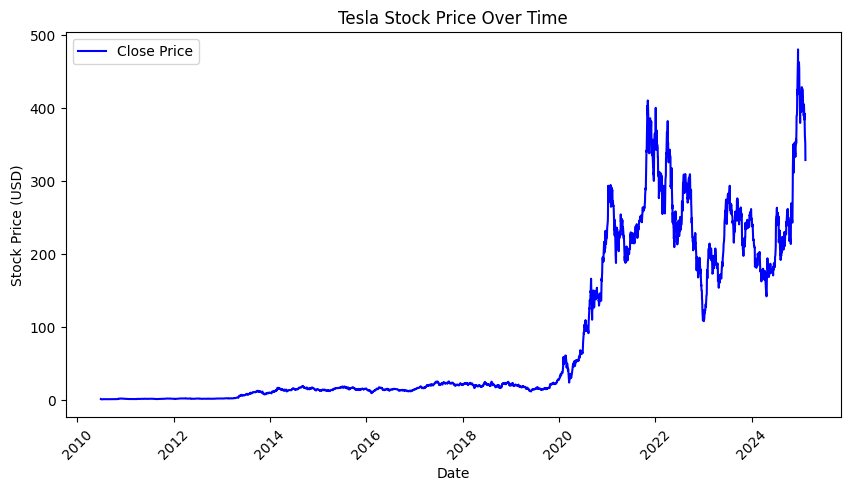

In [65]:
import matplotlib.pyplot as plt
def make_graph(data, title):
    plt.figure(figsize=(10,5))
    plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
    plt.xlabel("Date")
    plt.ylabel("Stock Price (USD)")
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)  
    plt.show()
make_graph(tesla_data, "Tesla Stock Price Over Time")

In [ ]:
#Question 6: Plot GameStop Stock Graph

#Use the make_graph function to graph the GameStop Stock Data, also provide a title for the graph.

#Upload a screenshot of your results.

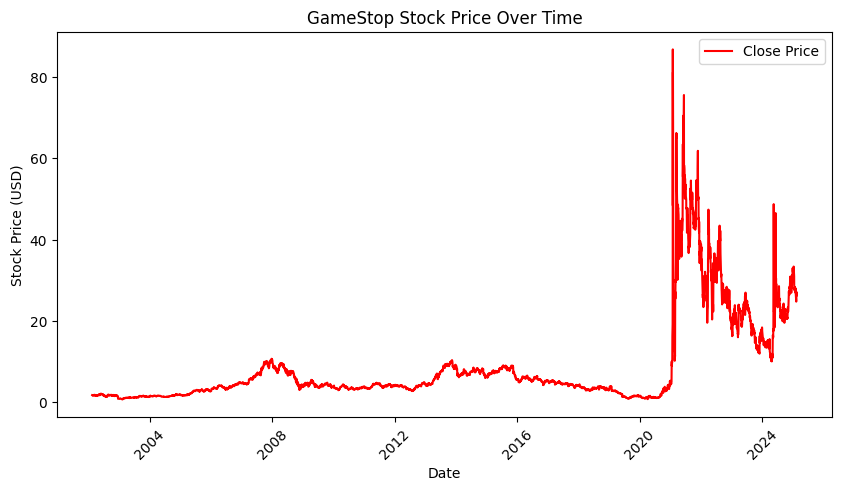

In [67]:
import matplotlib.pyplot as plt
def make_graph(data, title):
    plt.figure(figsize=(10,5))
    plt.plot(data['Date'], data['Close'], label='Close Price', color='red')
    plt.xlabel("Date")
    plt.ylabel("Stock Price (USD)")
    plt.title(title)
    plt.legend()
    plt.xticks(rotation=45)  
    plt.show()
make_graph(gme_data, "GameStop Stock Price Over Time")